Лабораторная работа №2
=
    
**Проведение исследований с логистической и линейной регрессией**

Классификация
=

**Импорт необходимых библиотек**

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_curve
import warnings
warnings.filterwarnings('ignore')

**Чтение данных и визуализация распределения**

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 944 entries, 0 to 943
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   footfall     944 non-null    int64
 1   tempMode     944 non-null    int64
 2   AQ           944 non-null    int64
 3   USS          944 non-null    int64
 4   CS           944 non-null    int64
 5   VOC          944 non-null    int64
 6   RP           944 non-null    int64
 7   IP           944 non-null    int64
 8   Temperature  944 non-null    int64
 9   fail         944 non-null    int64
dtypes: int64(10)
memory usage: 73.9 KB
Распределение целевой переменной:
fail
0    551
1    393
Name: count, dtype: int64


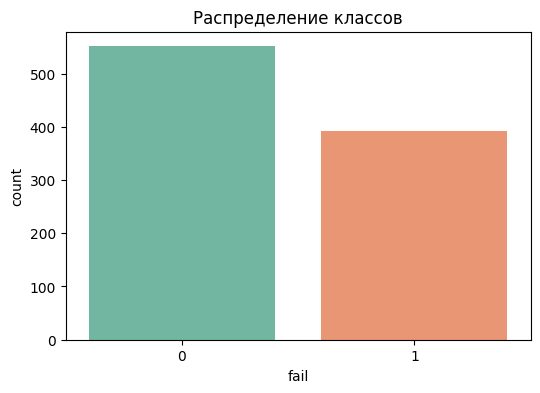

In [78]:
df = pd.read_csv('data_class.csv')
df.info()
columns = ['footfall', 'tempMode', 'AQ', 'USS', 'CS', 'VOC', 'RP', 'IP', 'Temperature', 'fail']
df.columns = columns

print("Распределение целевой переменной:")
print(df['fail'].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='fail', palette='Set2')
plt.title('Распределение классов')
plt.show()

**Лог-трансформация признаков**

In [79]:
log_cols = ['footfall', 'VOC', 'USS', 'CS', 'IP']
for col in log_cols:
    df[col] = np.log1p(df[col])  # log(1 + x)
df['sensor_ratio'] = df['AQ'] / (df['Temperature'] + 1e-6)
df['is_high_risk'] = (
    (df['VOC'] > df['VOC'].quantile(0.85)) & 
    (df['Temperature'] > df['Temperature'].quantile(0.85))
).astype(int)

**Создание бейзлайна**

In [80]:
X = df.drop('fail', axis=1)
y = df['fail']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

logreg_bl = LogisticRegression(max_iter=1000, random_state=42)
logreg_bl.fit(X_train, y_train)
y_pred_bl = logreg_bl.predict(X_test)

acc_bl = accuracy_score(y_test, y_pred_bl)
f1_bl = f1_score(y_test, y_pred_bl)

print(f"Accuracy: {acc_bl:.4f} | F1: {f1_bl:.4f}")

Accuracy: 0.9048 | F1: 0.8889


**Улучшение модели**

In [81]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

param_grid = {
    'C': [0.1, 1, 10, 100],
    'class_weight': ['balanced'] 
}

grid = GridSearchCV(
    LogisticRegression(max_iter=5000, random_state=42),
    param_grid,
    cv=5,
    scoring='f1'
)
grid.fit(X_train_scaled, y_train)

y_proba = grid.predict_proba(X_test_scaled)[:, 1]
best_f1, best_thresh = 0, 0.5
for thresh in np.arange(0.1, 9, 0.01):
    y_pred = (y_proba >= thresh).astype(int)
    f1 = f1_score(y_test, y_pred)
    if f1 > best_f1:
        best_f1, best_thresh = f1, thresh

y_pred_final = (y_proba >= best_thresh).astype(int)
acc_final = accuracy_score(y_test, y_pred_final)
f1_final = best_f1

print(f"Accuracy: {acc_final:.4f} | F1: {f1_final:.4f}")
print(f"Лучший порог: {best_thresh:.2f}")

Accuracy: 0.9206 | F1: 0.9007
Лучший порог: 0.70


**Собственная реализация логистической регрессии**

In [82]:
class MyLogisticRegression:
    def __init__(self, lr=0.01, n_iters=1000):
        self.lr = lr
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        z = np.clip(z, -500, 500)
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for _ in range(self.n_iters):
            linear_pred = np.dot(X, self.weights) + self.bias
            predictions = self._sigmoid(linear_pred)
            dw = (1 / n_samples) * np.dot(X.T, (predictions - y))
            db = (1 / n_samples) * np.sum(predictions - y)
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    def predict_proba(self, X):
        linear_pred = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_pred)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

**Обучение собственной реализации на сырых данных**

In [83]:
my_lr_base = MyLogisticRegression(lr=0.1, n_iters=2000)
my_lr_base.fit(X_train, y_train)
y_pred_custom_base = my_lr_base.predict(X_test)

acc_custom_base = accuracy_score(y_test, y_pred_custom_base)
f1_custom_base = f1_score(y_test, y_pred_custom_base)

print(f"Accuracy: {acc_custom_base:.4f} | F1: {f1_custom_base:.4f}")

Accuracy: 0.7407 | F1: 0.5505


**Обучение собственной реализации на чистых данных**

In [84]:
my_lr = MyLogisticRegression(lr=0.1, n_iters=2000)
my_lr.fit(X_train_scaled, y_train)
y_pred_custom = my_lr.predict(X_test_scaled, threshold=best_thresh)

acc_custom = accuracy_score(y_test, y_pred_custom)
f1_custom = f1_score(y_test, y_pred_custom)

print(f"Accuracy: {acc_custom:.4f} | F1: {f1_custom:.4f}")

Accuracy: 0.9206 | F1: 0.8993


**Вывод всех результатов**

In [85]:
results = pd.DataFrame({
    'Модель': ['Бейзлайн', 'Улучшенная модель', 'Собственная реализация сырая', 'Собственная модель чистая'],
    'Accuracy': [acc_bl, acc_final, acc_custom_base, acc_custom],
    'F1': [f1_bl, f1_final, f1_custom_base, f1_custom]
})
results

,Модель,Accuracy,F1
0,Бейзлайн,0.904762,0.888889
1,Улучшенная модель,0.920635,0.900662
2,Собственная реализация сырая,0.740741,0.550459
3,Собственная модель чистая,0.920635,0.899329


Регрессия
=

**Импорт библиотек**

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

**Загрузка данных и преобразование числовых столбцов**

In [95]:
df = pd.read_csv('data.csv', header=None)

columns = [
    'price', 'building_type', 'district', 'floor', 'city',
    'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony',
    'floor_level', 'renovation'
]
df.columns = columns

numeric_cols = ['price', 'floor', 'rooms', 'total_area', 'living_area', 'kitchen_area', 'balcony', 'floor_level']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')
df = df.dropna(subset=['price'])

df = df[df['price'] <= 120_000_000]
df = df[(df['total_area'] > 10) & (df['total_area'] <= 200)]
df = df[df['rooms'] > 0]
df['price_per_sqm'] = df['price'] / df['total_area']

print(f"Объектов после обработки: {len(df)}")

Объектов после обработки: 17182


**Визуализация распределения цен**

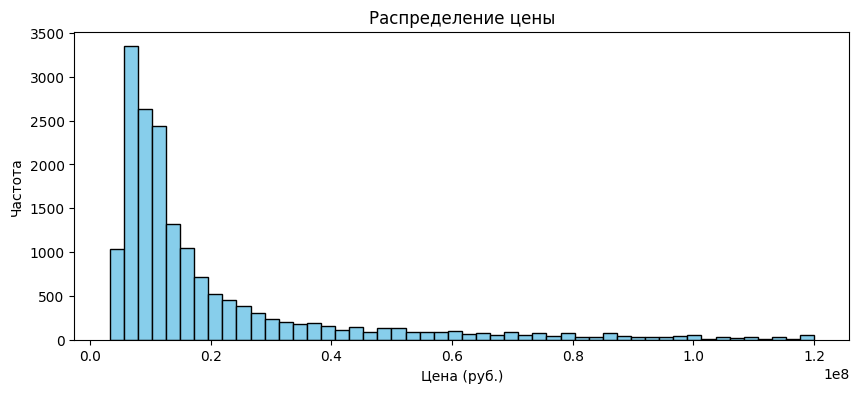

In [96]:
plt.figure(figsize=(10, 4))
plt.hist(df['price'], bins=50, color='skyblue', edgecolor='black')
plt.title('Распределение цены')
plt.xlabel('Цена (руб.)')
plt.ylabel('Частота')
plt.show()

**Просмотр матрицы корреляции**

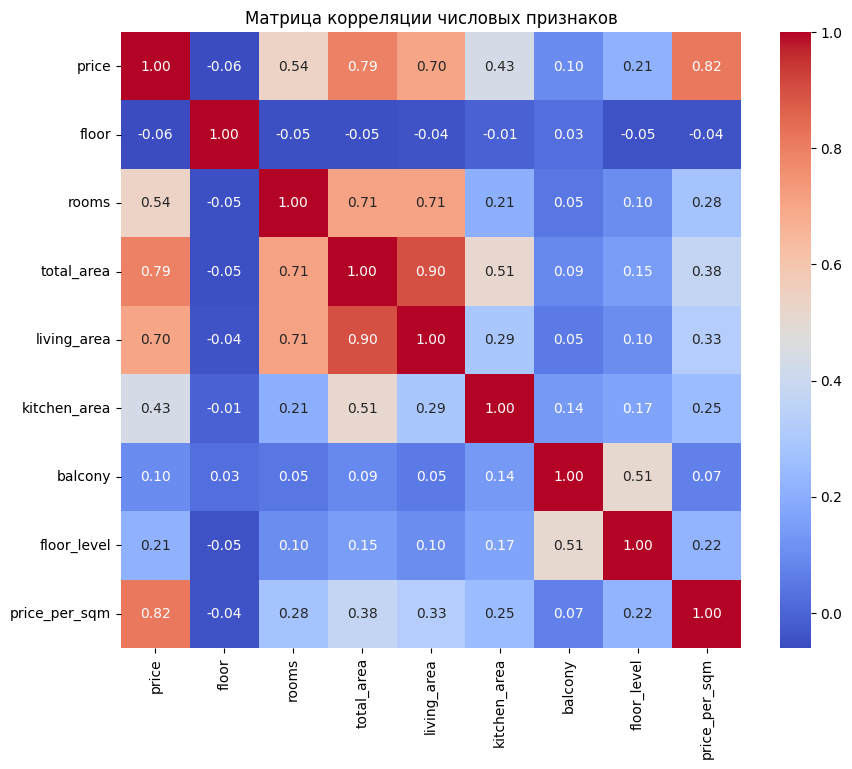

In [97]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Матрица корреляции числовых признаков')
plt.show()

**Создание бейзлайна**

In [98]:
X_all = df[numeric_cols].drop('price', axis=1)
y_all = df['price']

X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42)

linreg_bl = LinearRegression()
linreg_bl.fit(X_train, y_train)
y_pred_bl = linreg_bl.predict(X_test)

mae_bl = mean_absolute_error(y_test, y_pred_bl)
r2_bl = r2_score(y_test, y_pred_bl)

print(f"MAE: {mae_bl:,.0f} руб. | R²: {r2_bl:.4f}")

MAE: 8,233,933 руб. | R²: 0.6356


**Улучшение бейзлайна**

In [99]:
# Отбор признаков с корреляцией > 0.3 с price
corr = numeric_df.corr()['price'].abs().sort_values(ascending=False)
selected_features = corr[corr > 0.3].index.drop('price')
print("Признаки для улучшенной модели:", list(selected_features))

X_imp = df[selected_features]
y_imp = df['price']

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(X_imp, y_imp, test_size=0.2, random_state=42)

scaler_imp = StandardScaler()
X_train_imp_scaled = scaler_imp.fit_transform(X_train_imp)
X_test_imp_scaled = scaler_imp.transform(X_test_imp)

# Подбор регуляризации
param_grid = {'alpha': [0.1, 1, 10, 100, 1000]}
grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)
grid.fit(X_train_imp_scaled, y_train_imp)

y_pred_imp = grid.predict(X_test_imp_scaled)
mae_imp = mean_absolute_error(y_test_imp, y_pred_imp)
r2_imp = r2_score(y_test_imp, y_pred_imp)

print(f"MAE: {mae_imp:,.0f} руб. | R²: {r2_imp:.4f}")
print(f"Лучший alpha: {grid.best_params_['alpha']}")

Признаки для улучшенной модели: ['price_per_sqm', 'total_area', 'living_area', 'rooms', 'kitchen_area']
MAE: 3,413,983 руб. | R²: 0.9413
Лучший alpha: 100


**Собственная реализация**

In [100]:
class MyLinearRegression:
    def __init__(self):
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]
        self.weights = np.linalg.inv(X.T @ X) @ X.T @ y

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.weights

**Обучение собственной модели на сырых данных**

In [103]:
my_lr = MyLinearRegression()
my_lr.fit(X_train, y_train)
y_pred_custom_base = my_lr.predict(X_test)

mae_custom_base = mean_absolute_error(y_test, y_pred_custom_base)
r2_custom_base = r2_score(y_test, y_pred_custom_base)

print(f"MAE: {mae_custom_base:,.0f} руб. | R²: {r2_custom_base:.4f}")

MAE: 8,233,933 руб. | R²: 0.6356


**Обучение собственной реализации на чистых данных**

In [104]:
my_lr = MyLinearRegression()
my_lr.fit(X_train_imp_scaled, y_train_imp)
y_pred_custom = my_lr.predict(X_test_imp_scaled)

mae_custom = mean_absolute_error(y_test_imp, y_pred_custom)
r2_custom = r2_score(y_test_imp, y_pred_custom)

print(f"MAE: {mae_custom:,.0f} руб. | R²: {r2_custom:.4f}")

MAE: 3,427,001 руб. | R²: 0.9413


**Итоговая таблица**

In [106]:
results = pd.DataFrame({
    'Модель': ['Бейзлайн (все признаки)', 'Улучшенная модель', 'Собственная реализация грязная', 'Собственная реализация чистая'],
    'MAE (руб.)': [mae_bl, mae_imp, mae_custom_base, mae_custom],
    'R²': [r2_bl, r2_imp, r2_custom_base, r2_custom]
})
results

,Модель,MAE (руб.),R²
0,Бейзлайн (все признаки),8.233933e+06,0.635592
1,Улучшенная модель,3.413983e+06,0.941284
2,Собственная реализация грязная,8.233933e+06,0.635592
3,Собственная реализация чистая,3.427001e+06,0.941337
